# Nuclear NPV simulation

Run the nuclear electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_nuclear_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_nuclear_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,nuclear,1000000.0,5300.0,188.679245,188679.245283,7243.549221,96.952272,7.956456,2.898099,...,94070000.0,1.829288e+07,7.956456e+06,2.318479e+07,0.0,4.463587e+07,-8.902295e+08,25000000.0,-35.609180,-0.000036
1,1,nuclear,1000000.0,5300.0,188.679245,188679.245283,11021.182530,116.671896,7.962521,2.962486,...,94070000.0,2.201357e+07,7.962521e+06,2.369989e+07,0.0,4.039403e+07,-1.648271e+09,25000000.0,-65.930848,-0.000066
2,2,nuclear,1000000.0,5300.0,188.679245,188679.245283,13972.738115,110.751988,6.592729,2.915796,...,94070000.0,2.089660e+07,6.592729e+06,2.332637e+07,0.0,4.325430e+07,-2.174636e+09,25000000.0,-86.985429,-0.000087
3,3,nuclear,1000000.0,5300.0,188.679245,188679.245283,14427.889261,99.657554,6.119119,2.844154,...,94070000.0,1.880331e+07,6.119119e+06,2.275323e+07,0.0,4.639434e+07,-2.226994e+09,25000000.0,-89.079764,-0.000089
4,4,nuclear,1000000.0,5300.0,188.679245,188679.245283,7013.539443,94.230980,8.148999,3.006175,...,94070000.0,1.777943e+07,8.148999e+06,2.404940e+07,0.0,4.409217e+07,-8.526353e+08,25000000.0,-34.105410,-0.000034


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-1600.877699,-64.035108,-0.000064
std,545.293201,21.811728,0.000022
min,-2610.001474,-104.400059,-0.000104
5%,-2449.886705,-97.995468,-0.000098
50%,-1600.704824,-64.028193,-0.000064
95%,-751.773545,-30.070942,-0.000030
max,-598.283168,-23.931327,-0.000024


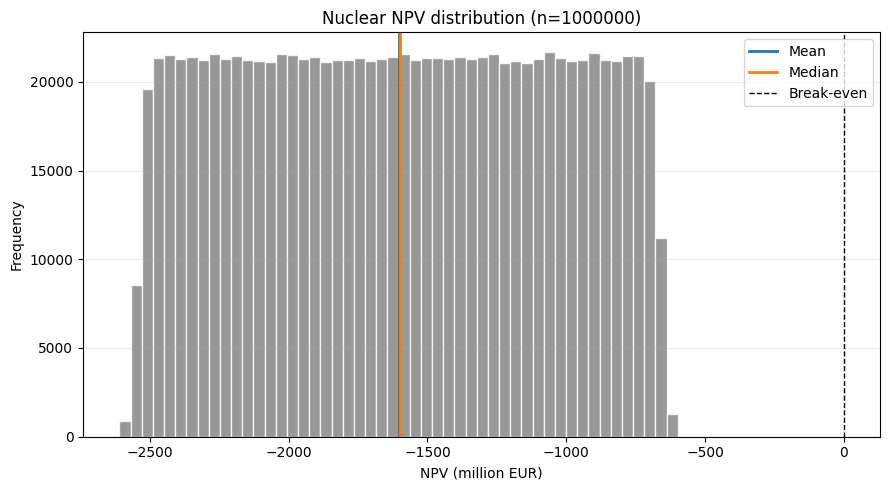

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


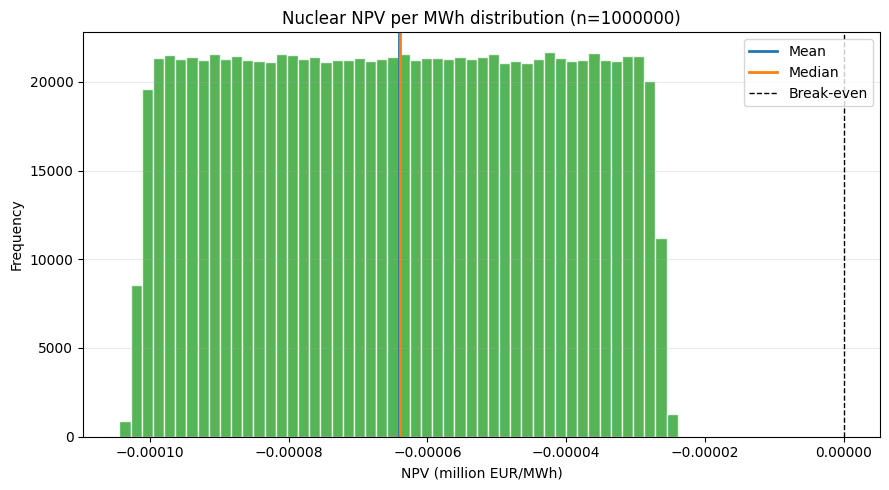

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        19.498411
annual_variable_opex_eur      7.232581
annual_fuel_cost_eur         22.880526
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     44.458482
Name: Mean annual value, million EUR, dtype: float64